<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; Kundframgångsanalys</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">Orsaksanalys för kundchurn</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">PROC FISHBONE orsak-verkan-diagram för en retentionsgranskning av mid-market B2B SaaS</div>
</div>

## Sammanfattning

Denna analys organiserar grundorsakerna till förhöjd kundchurn för en SaaS-tjänst i ett strukturerat orsak-verkan-diagram (Ishikawa). Mid-market B2B-segmentet tappar kunder i cirka 18 % takt årligen mot ett mål på 8 %. Tjugo grundorsaksfynd — hämtade från avgångsenkäter, intervjuer med kundframgångsteamet och kohortattribution — grupperas i sex orsakskategorier och renderas med `PROC FISHBONE` som ett diagram med 27 noder (en verkan, sex kategorigrenar, tjugo underorsaker).

Den kompletterande `PROC MEANS`-nedbrytningen visar var den tillskrivbara churnen koncentreras. **Produkt** har flest fynd (5 orsaker, 48,1 totala effektpoäng), följt av **Prissättning** (4 orsaker, 42,3) och **Support** (4 orsaker, 40,2). Mätt som genomsnittlig effekt *per orsak* är **Konkurrens** den allvarligaste kategorin (medelvärde 11,8), och det enskilt högst rankade fyndet totalt är **Prissättning**s förnyelseprishöjning utan förvarning (14,2). `PROC SGPLOT`-Pareto-vyn rangordnar varje enskild orsak så att ledningen kan se vilka grenar som ska åtgärdas först. Leveransen matar den kvartalsvisa retentionsgranskningen för kundframgångsteamet.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------|
| WORK.CHURN_RCA | Grundorsaksfynd för kundchurn sammanställda från avgångsenkätanalys och CS-teamets retrospektiv; varje rad är en orsak med sin kategori, stödjande belägg och uppskattad andel churnpåverkan | 20 |

---

In [1]:
/* --------------------------------------------------------
   Grundorsaksfynd för kundchurn (RCA)
   SaaS-plattform, B2B mid-market-segment.
   Varje rad: orsakskategori, den specifika orsaken, en
   stödjande underorsak/belägg-anteckning och den
   uppskattade andelen churn som kan tillskrivas den (från
   avgångsenkät och kohortattribution).
   -------------------------------------------------------- */
data work.churn_rca;
    INFILE DATALINES dlm='|' dsd truncover;
    INDATA category :$20. cause :$80. subcause :$100. churn_impact_pct;
    DATALINES;
Produkt|Kärnfunktionsluckor jämfört med enterprisekonkurrenter|Massexport och API-hastighetsgränser nämndes i 34% av avgångsenkäterna|12.4
Produkt|Begränsade rapporteringsmöjligheter|Ingen anpassningsbar dashboard-byggare i standardnivån|9.8
Produkt|Mobilappen ligger efter webbfunktionaliteten|3 viktiga arbetsflöden som enbart mobilanvändare inte kan slutföra|8.2
Produkt|Frekventa gränssnittsändringar utan förvarning|Erfarna användare störs av kvartalsvisa omdesigner|7.6
Produkt|Luckor i integrationsmarknaden|Saknar inbyggda kopplingar till Salesforce och HubSpot|10.1
Prissättning|Prishöjning vid förnyelse utan förvarning|18% ökning av MRR med 30 dagars varsel|14.2
Prissättning|Per-licens-modellen missgynnar teamtillväxt|Kostnaden fördubblas när teamet växer från 10 till 20|11.3
Prissättning|Den inledande rabatten kan inte förnyas|Prischock vid första förnyelsen|9.7
Prissättning|Inget incitament för flerårskontrakt|Årspriset är identiskt med månad-till-månad|7.1
Support|Första svarstiden överstiger 24 timmar|Nivåns riktvärde är 4 timmar|10.8
Support|Kvalitetslucka i helgsupporten|Offshore-bemanningen saknar produktkunskap|9.3
Support|Ingen dedikerad CSM under Enterprise-nivån|Mid-market-konton saknar namngiven kontaktperson|11.5
Support|Eskaleringsvägen är otydlig för kunderna|38% av de förlorade kontona angav förvirring kring eskalering|8.6
Introduktion|Tid till värde överstiger 90 dagar|Implementeringens komplexitet avslöjades inte före köp|12.9
Introduktion|Självbetjäningsdokumentationen är föråldrad|Senast uppdaterad för 11 månader sedan|8.1
Introduktion|Inga guidade rundturer i appen för nya funktioner|Funktionsanvändningen är under 30% efter 6 månader|9.4
Konkurrens|Konkurrent till 30% lägre pris|Tre stora konton namngav en specifik konkurrent|13.1
Konkurrens|Konkurrent erbjuder obegränsat antal licenser|Eliminerar per-licens-avgiften för växande team|10.6
Relation|Byte av ledningssponsor hanterades inte|Förespråkaren slutade; inget återengagemangsprogram|11.7
Relation|QBR-frekvensen minskades till årsvis|CS-teamets resurser minskades för 18 månader sedan|9.2
;
KÖR;




NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baslinje: koncentration av churnpåverkan per RCA-kategori.
   Summan visar var tillskrivbar churn klustras; max flaggar
   den värsta enskilda orsaken i varje kategori.
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.churn_rca n sum mean MAX maxdec=1;
    KLASS category;
    VARIABEL churn_impact_pct;
    ETIKETT category="Kategori" churn_impact_pct="Uppskattad churnpåverkan (%)";
    TITEL 'Kundchurn RCA: påverkan i procent per kategori';
KÖR;



                                     Kundchurn RCA: påverkan i procent per kategori                                     

                                                  The MEANS Procedure

                           Analysis Variable : churn_impact_pct Uppskattad churnpåverkan (%)

        Kategori               N Obs            Sum           Mean        Maximum
        -------------------------------------------------------------------------
        Introduktion               3           30.4           10.1           12.9
        Konkurrens                 2           23.7           11.8           13.1
        Prissättning               4           42.3           10.6           14.2
        Produkt                    5           48.1            9.6           12.4
        Relation                   2           20.9           10.4           11.7
        Support                    4           40.2           10.1           11.5
        -------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                     Kundchurn RCA: påverkan i procent per kategori                                     




NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


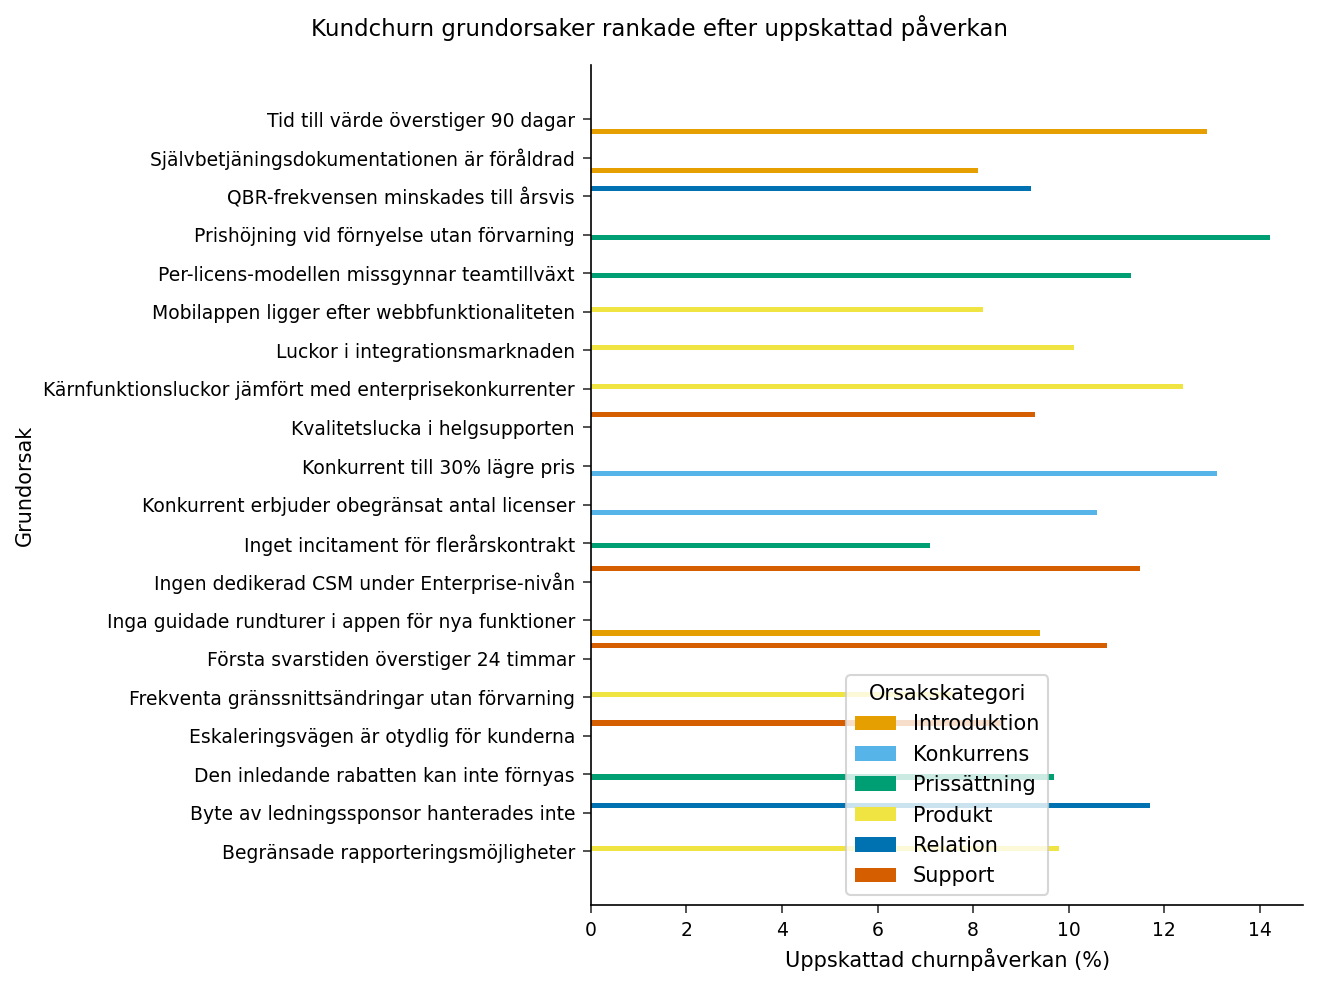

In [3]:
/* --------------------------------------------------------
   Pareto-vy: enskilda grundorsaker rangordnade efter
   uppskattad churnpåverkan, färgade efter kategori. Detta
   kompletterar fiskbensdiagrammet genom att kvantifiera
   vilka grenar som betyder mest.
   -------------------------------------------------------- */
PROCEDUR SORTERA data=work.churn_rca;
    EFTER FALLANDE churn_impact_pct;
KÖR;

PROCEDUR SGPLOT data=work.churn_rca;
    HBAR cause / RESPONSE=churn_impact_pct
        GROUP=category;
    XAXIS label='Uppskattad churnpåverkan (%)';
    YAXIS label='Grundorsak' discreteorder=data;
    keylegend / title='Orsakskategori' position=bottom;
    TITEL 'Kundchurn grundorsaker rankade efter uppskattad påverkan';
KÖR;


---

### Orsak-verkan-diagram (Ishikawa)

`PROC FISHBONE` bygger diagrammet direkt från `WORK.CHURN_RCA`: varje distinkt `category` blir en huvudgren från den centrala ryggraden, och de enskilda `cause`-fynden hänger som underorsaker från sin kategorigren. Proceduren skriver ut hela orsak-verkan-strukturen nedan — verkan i huvudet, de sex kategorigrenarna och varje underorsak grupperad under sin gren — och skriver den matchande fiskbensgrafiken till disk. Pareto-diagrammet ovan är följeslagarvyn som kvantifierar vilka av dessa grenar som bär mest tillskrivbar churn.

In [4]:
/* --------------------------------------------------------
   PROC FISHBONE: orsak-verkan-diagram för kundchurn.
   Diagrammet drivs direkt från WORK.CHURN_RCA, så de sex
   orsakskategorierna och deras orsaker är exakt de fynd
   som analyserats ovan. CATEGORY bildar huvudgrenarna;
   CAUSE hänger som underorsaker från varje gren.
   -------------------------------------------------------- */
PROCEDUR fishbone data=work.churn_rca;
    cause category / subcause=cause;
    effect 'Förhöjd kundchurn (18% årligen mot 8% mål)';
    TITEL 'Kundchurn - orsaksanalys för mid-market-segmentet';
    footnote 'Källor: avgångsenkäter, samtal med CS-teamet, kohortattribution';
KÖR;



                                     Kundchurn RCA: påverkan i procent per kategori                                     


                    Kundchurn - orsaksanalys för mid-market-segmentet
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] Förhöjd kundchurn (18% årligen mot 8% mål)
    [CAUSE] Prissättning (top)
      [SUB] Prishöjning vid förnyelse utan förvarning
      [SUB] Per-licens-modellen missgynnar teamtillväxt
      [SUB] Den inledande rabatten kan inte förnyas
      [SUB] Inget incitament för flerårskontrakt
    [CAUSE] Konkurrens (top)
      [SUB] Konkurrent till 30% lägre pris
      [SUB] Konkurrent erbjuder obegränsat antal licenser
    [CAUSE] Introduktion (top)
      [SUB] Tid till värde överstiger 90 dagar
      [SUB] Inga guidade rundturer i appen för nya funktioner
      [SUB] Självbetjäningsdokumentationen är föråldrad
    [CAUSE] Produkt (bottom)
      [SUB] Kärnfunktionsluckor jämfört med enterprisekonkurrenter
      [SUB] Lucko


NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### Tolkning

Orsak-verkan-strukturen och `PROC MEANS`-siffrorna per kategori pekar ut ett litet antal högeffektiva åtgärder för ledningen. De två högst rankade enskilda orsaksfynden — **Prissättning**s förnyelseprishöjning utan förvarning (14,2) och **Konkurrens**-fyndet att en rival säljer likvärdig kapacitet till 30 % lägre pris (13,1) — är båda kommersiella snarare än produktrelaterade frågor, vilket tyder på att pristransparens och konkurrenspositionering är de mest angelägna kortsiktiga hävstängerna. **Introduktion**ens tid-till-värde som överstiger 90 dagar (12,9) är det största fyndet på tjänstesidan och kopplar direkt till förväntningsbilden som sätts före köp.

Räknat i volym dominerar **Produkt** diagrammet (5 av 20 fynd, 48,1 totala effektpoäng), men dess fynd är individuellt mindre (medelvärde 9,6) än de i **Konkurrens** (medelvärde 11,8) eller **Prissättning** (medelvärde 10,6) — en påminnelse om att en lång lista med produktluckor inte automatiskt är högsta prioritet. **Relation**s-grenen (byte av ledningssponsor och minskad QBR-frekvens, 20,9 sammanlagt) representerar processförändringar som CS-teamet kan genomföra inom innevarande kvartal utan produkt- eller prisinvestering, vilket erbjuder den snabbaste vägen till mätbar retentionsförbättring. Den fullständiga rangordnade listan i Pareto-diagrammet låter ledningsteamet sekvensera insatser efter uppskattad effekt snarare än efter kategoristorlek.

---

In [5]:
/* --------------------------------------------------------
   Exportera RCA-fynd för kundchurn till strategiunderlag
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.churn_rca
    OUTFILE='customer_churn_rca_findings.csv'
    DBMS=csv REPLACE;
KÖR;



NOTE: PROC EXPORT data=work.churn_rca outfile=customer_churn_rca_findings.csv

NOTE: Exported 20 rows to customer_churn_rca_findings.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>